In [6]:
import mujoco
from IPython.display import clear_output
import math
import time
import jax
import jax.numpy as jp
from mujoco_playground._src.locomotion.knob.environment import KnobEnv
import seaborn as sns
import pyinstrument

In [7]:

model = mujoco.MjModel.from_xml_path(
    "/home/aizej/Desktop/disky/500GB_2025/gen/kodezy/python/mujoco_RL/mujoco_playground/mujoco_playground/_src/locomotion/knob/xmls/knob.xml"
)
print(model.nq, model.nv, model.nu)  # should print your joint/actuator counts

1 1 1


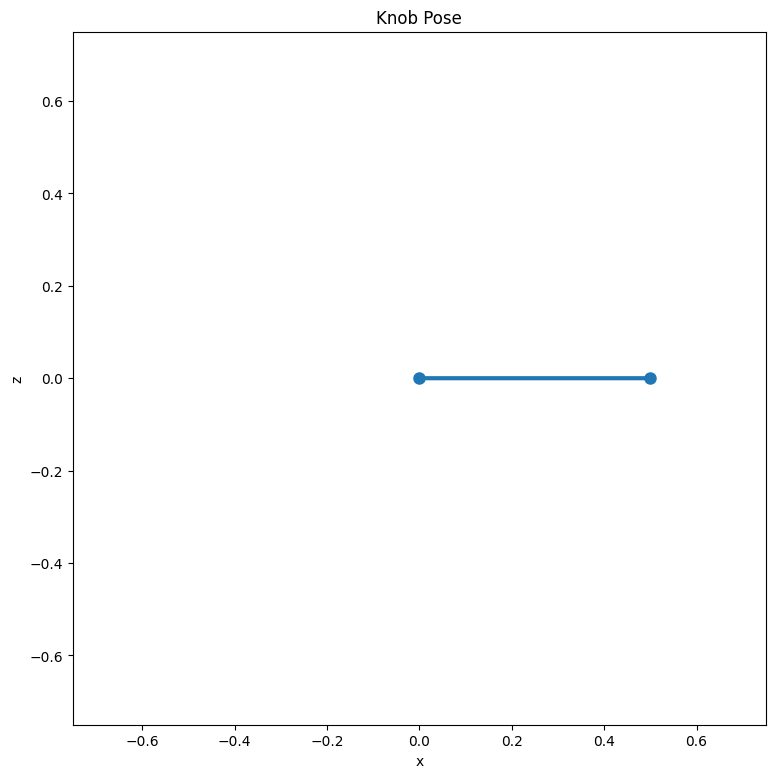

Step 500, reward: -0.0200, angles: [-1.5707974e+00 -2.2495412e-06 -1.1165949e-06 -1.0000000e+00],  -1.4130254983901978
✓ 100 steps completed, final reward: -0.0200


In [8]:

# 1. Create the environment



env = KnobEnv(config_overrides={"task": "setpoint1"})
#env = DoublePendulumEnv(config_overrides={"task": "swingup"})
print("✓ Environment created")
print(f"  action_size: {env.action_size}")
print(f"  xml_path: {env.xml_path}")
print(f"env._config.task: {env._config.task}")

# 2. Test reset
rng = jax.random.PRNGKey(0)
state = env.reset(rng)
print("\n✓ Reset successful")
print(f"  obs shape:    {state.obs.shape}")       # should be (6,)
print(f"  reward:       {state.reward}")          # should be 0.0
print(f"  done:         {state.done}")            # should be 0.0

# 3. Test a single step with random action
rng, action_rng = jax.random.split(rng)
action = jax.random.uniform(action_rng, (env.action_size,), minval=-1.0, maxval=1.0)
state = env.step(state, action)
print("\n✓ Step successful")
print(f"  obs shape:    {state.obs.shape}")       # should be (6,)
print(f"  reward:       {state.reward}")          # should be a float
print(f"  done:         {state.done}")            # should be 0.0 unless NaN


K_krit = 35
P_krit = 0.312
K=0.6*K_krit #35 is where system becomes periodical
Ti=0.5*P_krit
Td=0.125*P_krit
setpoint = -jp.pi/2
position_e_integrant = 0
position_e_old = 0
e_vect = []
# 4. Test a full rollout
rewards = []
print("\nRunning 100 steps...")
for i in range(500):
    
    position, speed = state.obs[:2]
    position_e = setpoint-position
    position_e_integrant += position_e*env._ctrl_dt


    position_e_derivand = (position_e-position_e_old)/env._ctrl_dt
    position_e_old = position_e
    e_vect.append(position_e.item())
    

    action = K*(position_e + 1/Ti*position_e_integrant + Td*position_e_derivand)
    state = env.step(state, action)

    rewards.append(state.reward.item())
    clear_output(wait=True)
    
    env.simple_render(state)
    print(f"Step {i+1}, reward: {state.reward:.4f}, angles: {state.obs[:4]},  {action}")

print(f"✓ 100 steps completed, final reward: {state.reward:.4f}")

<Axes: >

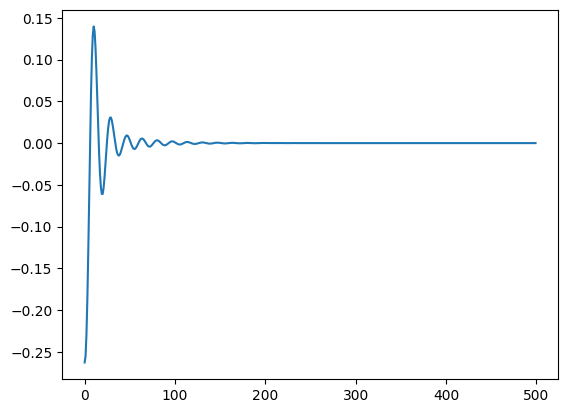

In [9]:
sns.lineplot(e_vect)


Dominant frequency: 2.800 Hz
Oscillation period: 0.357 s


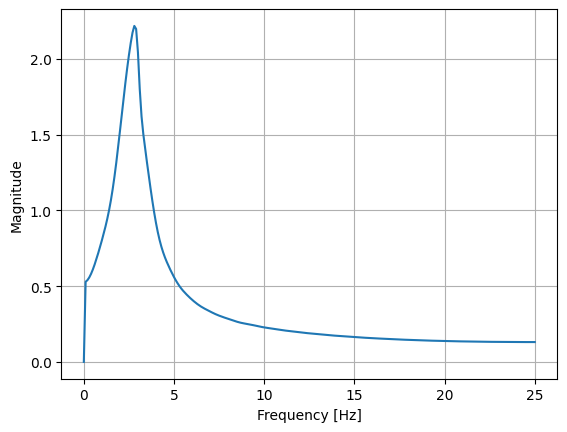

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy array
e = np.asarray(e_vect)

# Remove DC component (important!)
e = e - np.mean(e)

# Sampling frequency
dt = env._ctrl_dt
fs = 1.0 / dt

# FFT
fft = np.fft.rfft(e)
freqs = np.fft.rfftfreq(len(e), d=dt)

# Magnitude spectrum
mag = np.abs(fft)

# Ignore the zero-frequency bin
mag[0] = 0

# Dominant frequency
idx = np.argmax(mag)
f_peak = freqs[idx]

# Oscillation period
P = 1.0 / f_peak

print(f"Dominant frequency: {f_peak:.3f} Hz")
print(f"Oscillation period: {P:.3f} s")

# Plot
plt.plot(freqs, mag)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()